Β.2.β. Κανονικοποίηση/Τυποποίηση χαρακτηριστικών

In [1]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

Προεπεξεργασία εικόνων:
- μετατροπή σε έναν πίνακα μορφής (n_samples, height, width, channels), 
<br> για να μπορούμε να κάνουμε στατιστικά ανά κανάλι και να έχουμε πλήρη πρόσβαση σε κάθε pixel για επεξεργασία, ανάλυση, visualization κλπ

In [2]:
def load_images_from_folder(folder, target_size=(200, 200)):
    images = []
    for filename in os.listdir(folder):
        if filename.endswith('.jpg'):
            img_path = os.path.join(folder, filename)
            img = Image.open(img_path).convert('RGB')  # ensure RGB
            img = img.resize(target_size)
            images.append(np.array(img))
    return np.array(images)

sunny_images = load_images_from_folder('data/train/sunny')
cloudy_images = load_images_from_folder('data/train/cloudy')

# Συνένωση των δεδομένων
all_images = np.concatenate((sunny_images, cloudy_images), axis=0)
labels = np.array([1]*len(sunny_images) + [0]*len(cloudy_images))  # 1=sunny, 0=cloudy

print(f'Shape of image array: {all_images.shape}')  # (n_samples, 200, 200, 3)

Shape of image array: (10000, 200, 200, 3)


In [ ]:
# # Αποθήκευση του πίνακα εικόνων και των ετικετών
# np.save('all_images.npy', all_images)
# np.save('labels.npy', labels)

----

Χρήση Min-Max Scaling [0,1] και Standard Scaling (Z-score) για μεθόδους κανονικοποίησης με scikit-learn

In [3]:
images = all_images.reshape(-1, 3)  # κάνε flatten τις εικόνες σου ως RGB vectors

# Min-Max Scaling
minmax_scaler = MinMaxScaler()
images_minmax = minmax_scaler.fit_transform(images)

# Standard Scaling
std_scaler = StandardScaler()
images_std = std_scaler.fit_transform(images)

Σύγκριση κατανομών πριν και μετά την κλιμάκωση

In [ ]:
for i, color in enumerate(['Red', 'Green', 'Blue']):
    plt.hist(images[:, i], bins=50, alpha=0.5, label=f'Original {color}')
    plt.hist(images_minmax[:, i], bins=50, alpha=0.5, label=f'MinMax {color}')
    plt.hist(images_std[:, i], bins=50, alpha=0.5, label=f'Std {color}')
    plt.legend()
    plt.title(f'{color} Channel Distributions')
    plt.show()

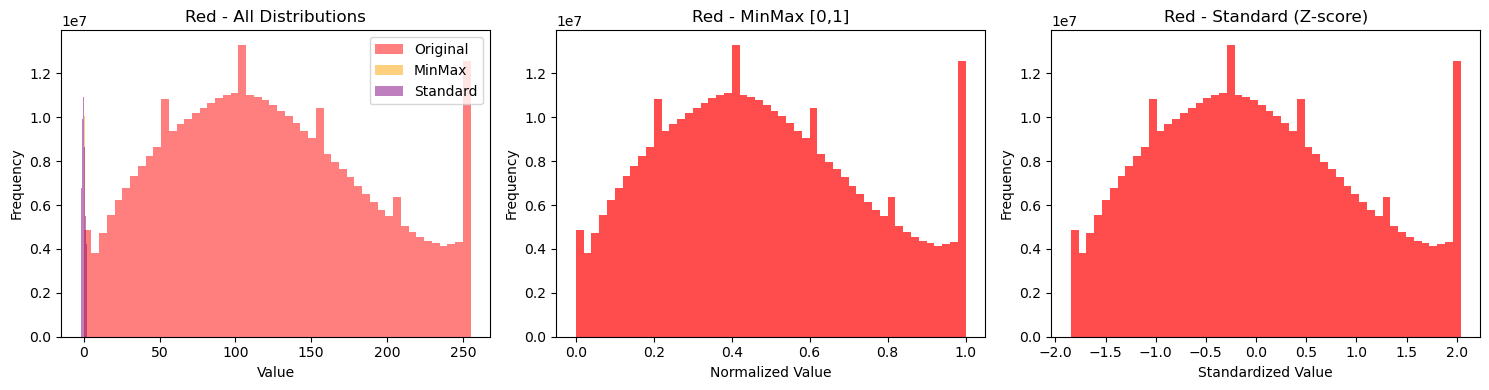

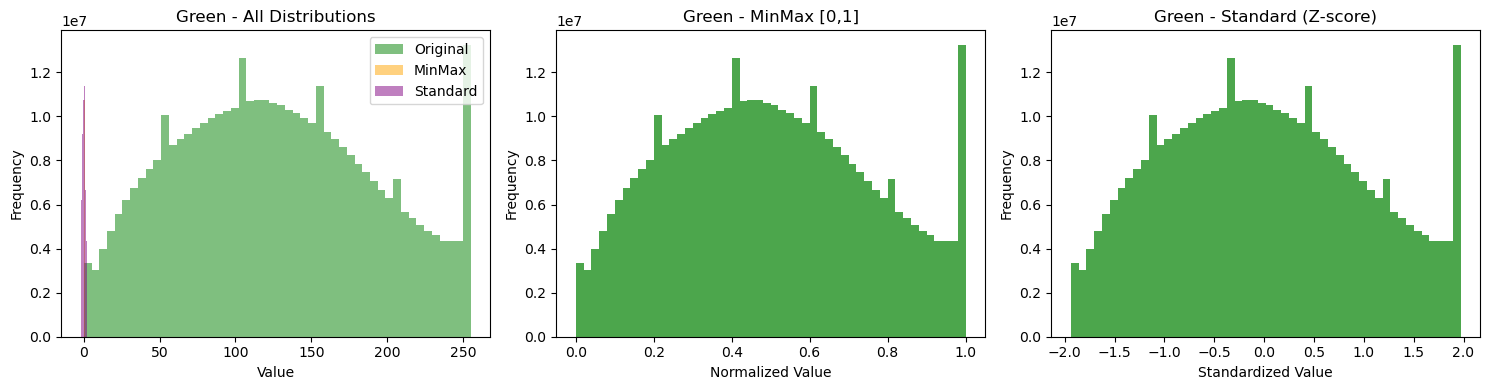

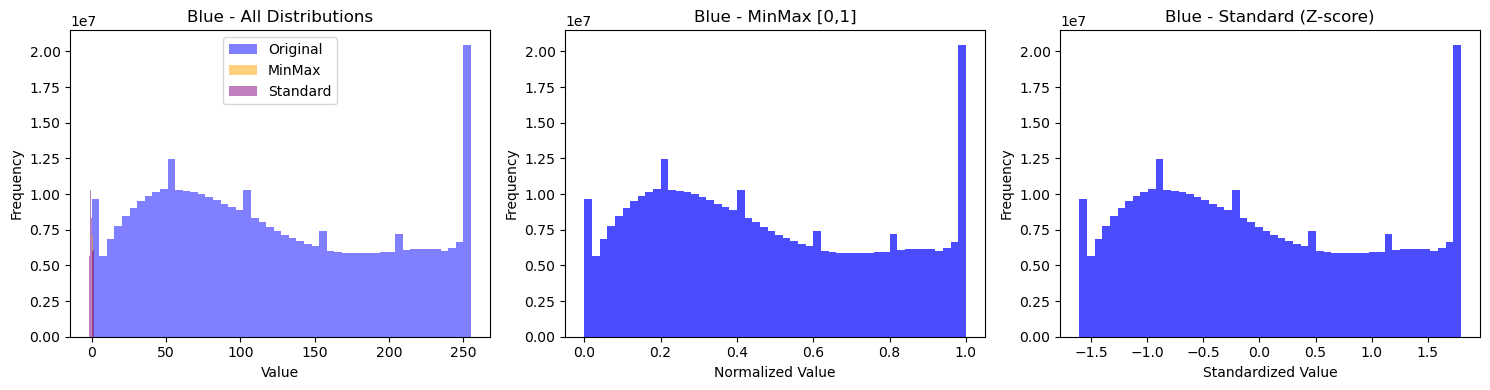

In [9]:
channel_names = ['Red', 'Green', 'Blue']
channel_indices = [0, 1, 2]
colors_map = {'Red': 'red', 'Green': 'green', 'Blue': 'blue'}

for i, color in zip(channel_indices, channel_names):
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    # axs[0] - Όλες οι κατανομές μαζί
    axs[0].hist(images[:, i], bins=50, color=colors_map[color], alpha=0.5, label='Original')
    axs[0].hist(images_minmax[:, i], bins=50, color='orange', alpha=0.5, label='MinMax')
    axs[0].hist(images_std[:, i], bins=50, color='purple', alpha=0.5, label='Standard')
    axs[0].set_title(f'{color} - All Distributions')
    axs[0].set_xlabel('Value')
    axs[0].set_ylabel('Frequency')
    axs[0].legend()

    # axs[1] - Μόνο MinMax
    axs[1].hist(images_minmax[:, i], bins=50, color=colors_map[color], alpha=0.7)
    axs[1].set_title(f'{color} - MinMax [0,1]')
    axs[1].set_xlabel('Normalized Value')
    axs[1].set_ylabel('Frequency')

    # axs[2] - Μόνο Standard
    axs[2].hist(images_std[:, i], bins=50, color=colors_map[color], alpha=0.7)
    axs[2].set_title(f'{color} - Standard (Z-score)')
    axs[2].set_xlabel('Standardized Value')
    axs[2].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()


In [ ]:
from torchvision import transforms

In [ ]:
# MinMax Scaling Κανονικοποίησης
transform_minmax = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),  # διαιρεί κάθε pixel με 255 και τα μετατρέπει σε float32 [0,1] - MinMax Scaling Κανονικοποιήση
])

In [ ]:
# Από τα στατιστικά που συλλέξαμε στο B1a
mean = [121.17 / 255, 126.45 / 255, 120.32 / 255]
std = [65.67 / 255, 65.26 / 255, 75.04 / 255]


transform_standard = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])


Έτσι εφαρμόζουμε τις μεθόδους κανονικοποίησης μέσω Pytorch και χρησιμοποιούμε το customized transform που δημιουργήσαμε κατά τη φόρτωση του dataset και τη δημιουργία του data_loader

----